# Invest-a-Bull ? Live Top 5 Trending Stocks Notebook

This notebook is the analyst-facing companion to the package pipeline. It can run interactively or be executed automatically by the daily GitHub workflow.

Run the cells from top to bottom to:

1. refresh or load the latest top-5 analysis artifacts
2. review portfolio and Monte Carlo outputs
3. inspect data-quality and report metadata
4. compare low-, medium-, and high-risk allocation scenarios

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'src').exists() and (candidate / 'README.md').exists():
            return candidate
    raise FileNotFoundError('Could not locate the Invest-a-Bull project root.')

PROJECT_ROOT = find_project_root(Path.cwd())
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from MCForecastTools import MCSimulation
from invest_a_bull.config import AnalysisConfig
from invest_a_bull.pipeline import run_pipeline

plt.style.use('seaborn-v0_8')
pd.options.display.float_format = '{:,.4f}'.format

In [2]:
capital = 15_000
duration_years = 1
top_n = 5
refresh_pipeline = os.environ.get('INVEST_A_BULL_NOTEBOOK_REFRESH', '1') == '1'

config = AnalysisConfig(
    project_root=PROJECT_ROOT,
    top_n=top_n,
    monte_carlo_days=252 * duration_years,
    monte_carlo_simulations=250,
)

display(Markdown(
    f"**Capital assumption:** ${capital:,.0f}  \
**Forecast horizon:** {duration_years} year(s)  \
**Top N selection:** {top_n}  \
**Refresh pipeline in-notebook:** {refresh_pipeline}"
))

**Capital assumption:** $15,000  **Forecast horizon:** 1 year(s)  **Top N selection:** 5  **Refresh pipeline in-notebook:** False

In [3]:
def latest_output_paths(cfg: AnalysisConfig) -> dict[str, Path]:
    return {
        'top_selection': cfg.data_dir / 'latest_top5_selection.csv',
        'top_prices': cfg.data_dir / 'latest_top5_prices.csv',
        'portfolio_summary': cfg.data_dir / 'latest_portfolio_summary.csv',
        'monte_carlo_summary': cfg.data_dir / 'latest_monte_carlo_summary.csv',
        'metadata': cfg.data_dir / 'latest_run_metadata.json',
        'report': cfg.reports_dir / 'latest_top5_stock_report.md',
        'data_quality_report': cfg.reports_dir / 'data_quality_report.md',
    }

outputs = run_pipeline(config) if refresh_pipeline else latest_output_paths(config)
metadata = json.loads(Path(outputs['metadata']).read_text(encoding='utf-8'))
top_selection = pd.read_csv(outputs['top_selection'])
top_prices = pd.read_csv(outputs['top_prices'], index_col=0, parse_dates=True)
portfolio_summary = pd.read_csv(outputs['portfolio_summary'])
mc_summary = pd.read_csv(outputs['monte_carlo_summary'], index_col=0).iloc[:, 0]

artifact_table = pd.DataFrame({
    'Artifact': list(outputs.keys()),
    'Path': [str(Path(path).relative_to(PROJECT_ROOT)).replace('\\', '/') for path in outputs.values()],
})

display(Markdown(
    f"**Generated:** {metadata['generated_at_utc']}  \
**Data as of:** {metadata['data_as_of']}  \
**Selection source:** {metadata['selection_source']}  \
**Selected tickers:** {', '.join(metadata['selected_tickers'])}"
))
top_selection

**Generated:** 2026-05-04T05:19:37.261840+00:00  **Data as of:** 2026-05-01  **Selection source:** yfinance_screeners  **Selected tickers:** MU, AMD, AAOI, NVDA, INTC

,rank,symbol,name,screen_hits,screens,price,day_change_pct,market_cap,avg_volume_3m,screen_presence_score,...,ann_volatility,max_drawdown,dollar_volume,screen_hits_norm,day_change_pct_norm,return_5d_norm,return_21d_norm,return_63d_norm,dollar_volume_norm,trend_score
0,1,MU,"Micron Technology, Inc.",2,"growth_technology_stocks, most_actives",542.2100,4.8438,611468705792,41131698,1.0000,...,0.7134,-0.3028,"22,302,018,876.3527",1.0000,0.4837,0.6100,0.5148,0.1764,0.6435,0.5900
1,2,AMD,"Advanced Micro Devices, Inc.",2,"growth_technology_stocks, most_actives",360.5400,1.7067,587828363264,37488175,1.0000,...,0.6308,-0.2647,"13,515,986,934.8335",1.0000,0.4182,0.4931,0.6945,0.2376,0.3883,0.5695
2,3,AAOI,"Applied Optoelectronics, Inc.",1,day_gainers,183.4400,11.5612,14683943936,10868851,0.5000,...,1.5763,-0.4101,"1,994,542,787.3056",0.0000,0.6239,0.6951,1.0000,1.0000,0.0537,0.5559
3,4,NVDA,NVIDIA Corporation,2,"growth_technology_stocks, most_actives",198.4500,-0.5612,4823327440896,174226236,1.0000,...,0.3634,-0.2015,"34,575,196,002.5037",1.0000,0.3709,0.3151,0.2579,0.1000,1.0000,0.5195
4,5,INTC,Intel Corporation,1,most_actives,99.6100,5.4186,500639858688,104736005,0.5000,...,0.7790,-0.2417,"10,433,801,105.7660",0.0000,0.4957,0.8552,0.9619,0.4139,0.2988,0.5019


In [4]:
display(Markdown('## Saved artifacts'))
artifact_table

## Saved artifacts

,Artifact,Path
0,top_selection,data/processed/latest_top5_selection.csv
1,top_prices,data/processed/latest_top5_prices.csv
2,portfolio_summary,data/processed/latest_portfolio_summary.csv
3,monte_carlo_summary,data/processed/latest_monte_carlo_summary.csv
4,metadata,data/processed/latest_run_metadata.json
5,report,reports/latest_top5_stock_report.md
6,data_quality_report,reports/data_quality_report.md


In [5]:
display(Markdown('## Portfolio summary'))
portfolio_summary

display(Markdown('## Monte Carlo summary'))
mc_summary.to_frame('value')

## Portfolio summary

## Monte Carlo summary

,value
count,250.0000
mean,5.7854
std,3.7341
min,1.3311
25%,3.4675
50%,5.0557
75%,7.0295
max,29.5773
95% CI Lower,1.6195
95% CI Upper,13.7709


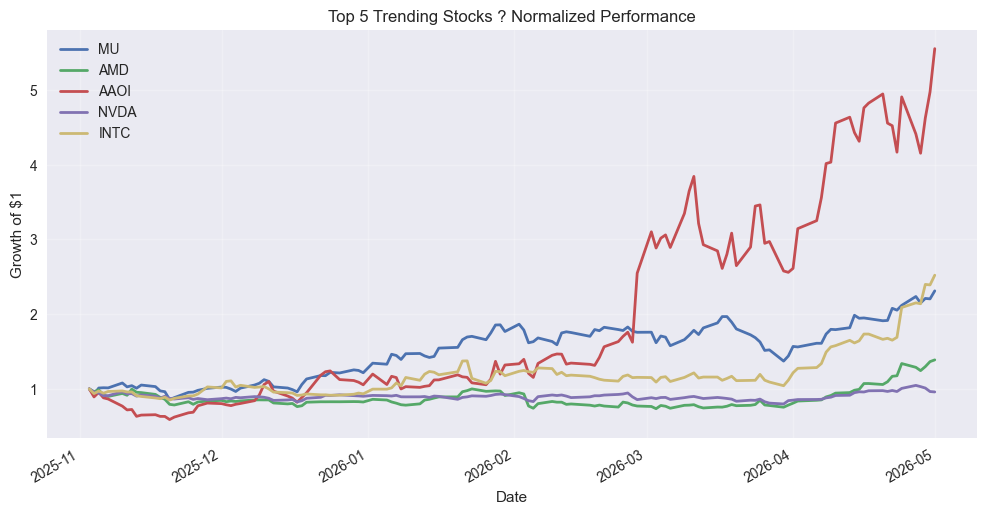

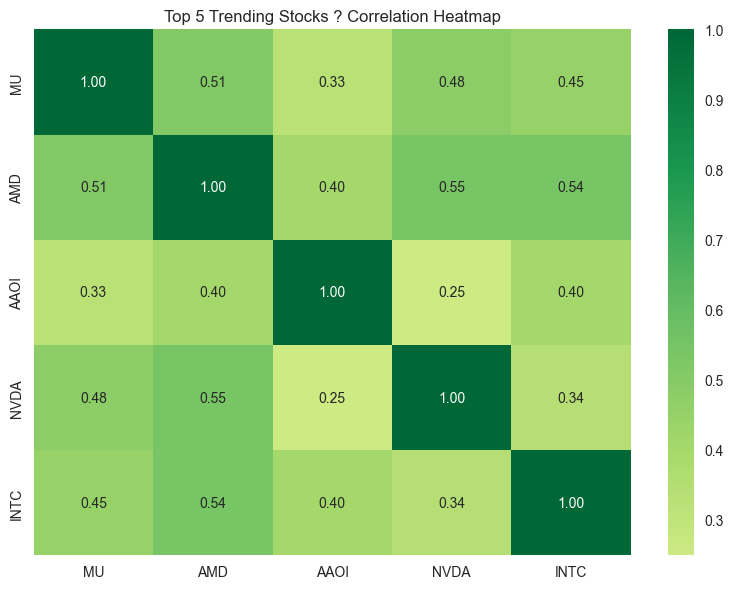

In [6]:
normalized_prices = top_prices / top_prices.iloc[0]
ax = normalized_prices.plot(figsize=(12, 6), linewidth=2)
ax.set_title('Top 5 Trending Stocks ? Normalized Performance')
ax.set_ylabel('Growth of $1')
ax.set_xlabel('Date')
ax.grid(alpha=0.25)
plt.show()

returns = top_prices.pct_change().dropna()
corr = returns.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='RdYlGn', center=0, fmt='.2f')
plt.title('Top 5 Trending Stocks ? Correlation Heatmap')
plt.tight_layout()
plt.show()

In [7]:
display(Markdown('## Latest report excerpts'))
display(Markdown(Path(outputs['report']).read_text(encoding='utf-8').split('## Disclaimer')[0]))
display(Markdown('## Data quality report'))
display(Markdown(Path(outputs['data_quality_report']).read_text(encoding='utf-8')))

## Latest report excerpts

# Invest-a-Bull Senior Market Report

Generated: 2026-05-04 05:19:37 UTC

## Executive summary

This report identifies the **top 5 trending U.S. stocks** using a blended ranking model that combines:

- current Yahoo Finance screener presence
- latest 1-day move
- trailing 5-day, 1-month, and 3-month momentum
- liquidity via average 3-month dollar volume
- minimum-history preference for more decision-useful names

Data source: `yfinance_screeners`  
Universe size after filtering: **40 stocks**  
Latest market data used in the report: **2026-05-01**

### Key takeaways

- Selected basket: **MU, AMD, AAOI, NVDA, INTC**
- Lookback portfolio return: **135.19%**
- Relative performance vs benchmark: **129.13%**
- Monte Carlo expected terminal return: **478.54%**
- Monte Carlo 95% range: **61.95% to 1277.09%**

## Top 5 trending stocks

| Rank | Ticker | Company | Source Screens | Trend Score | 1D Move | 5D Return | 1M Return | 3M Return | Market Cap | Avg 3M Volume | History Rows |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 1 | MU | Micron Technology, Inc. | growth_technology_stocks, most_actives | 0.590 | 4.84% | 9.16% | 47.40% | 30.75% | $611.5B | 41.1M | 124 |
| 2 | AMD | Advanced Micro Devices, Inc. | growth_technology_stocks, most_actives | 0.569 | 1.71% | 3.66% | 71.51% | 52.30% | $587.8B | 37.5M | 124 |
| 3 | AAOI | Applied Optoelectronics, Inc. | day_gainers | 0.556 | 11.56% | 13.16% | 112.52% | 320.80% | $14.7B | 10.9M | 124 |
| 4 | NVDA | NVIDIA Corporation | growth_technology_stocks, most_actives | 0.519 | -0.56% | -4.72% | 12.92% | 3.84% | $4,823.3B | 174.2M | 124 |
| 5 | INTC | Intel Corporation | most_actives | 0.502 | 5.42% | 20.69% | 107.41% | 114.37% | $500.6B | 104.7M | 124 |

## Portfolio view

The selected names are combined into an equal-weight portfolio to estimate how the current trend basket behaves as a single product.

| Metric | Value |
| --- | --- |
| Portfolio total return (lookback) | 135.19% |
| Portfolio annualized return | 193.84% |
| Portfolio annualized volatility | 60.42% |
| Portfolio Sharpe ratio | 3.14 |
| Portfolio max drawdown | -18.91% |
| SPY total return (lookback) | 6.06% |

## Monte Carlo outlook

A 1-year bootstrap Monte Carlo simulation is run on the equal-weight basket using stabilized empirical portfolio returns.

| Metric | Value |
| --- | --- |
| count | 250 |
| mean | 478.54% |
| std | 373.41% |
| min | 33.11% |
| 25% | 246.75% |
| 50% | 405.57% |
| 75% | 602.95% |
| max | 2857.73% |
| 95% CI Lower | 61.95% |
| 95% CI Upper | 1277.09% |

## Visual outputs

- Normalized price chart: `reports/figures/top5_normalized_performance.png`
- Correlation heatmap: `reports/figures/top5_correlation_heatmap.png`

## Methodology notes

1. Pull candidate names from Yahoo predefined screens: `most_actives`, `day_gainers`, and `growth_technology_stocks`.
2. Filter for listed U.S. equities and require minimum price and market-cap thresholds.
3. Download the latest daily adjusted-close history and prefer names with at least a 3-month lookback when available.
4. Rank names using a weighted composite trend score and keep the top 5.
5. Produce an equal-weight portfolio view and a scenario range for decision support.



## Data quality report

# Data Quality Report

Generated: 2026-05-04 05:19:37 UTC

- Latest market data used: **2026-05-01**
- Candidate universe count: **40**
- Eligible securities with sufficient history: **38**
- Selected top-n count: **5**
- Price-history row count: **124**
- Missing values in selected price matrix: **0**
- Selection source: `yfinance_screeners`
- Minimum history threshold for preferred selection: **63 trading days**
- Candidates excluded for insufficient history before fallback handling: **2**

The pipeline rejects empty universes, removes non-equity results, and keeps only symbols with downloadable price history.

## Selected ticker coverage

| Ticker | Observations | History Start | History End | Missing Cells | Meets Minimum History |
| --- | --- | --- | --- | --- | --- |
| MU | 124 | 2025-11-03 | 2026-05-01 | 0 | Yes |
| AMD | 124 | 2025-11-03 | 2026-05-01 | 0 | Yes |
| AAOI | 124 | 2025-11-03 | 2026-05-01 | 0 | Yes |
| NVDA | 124 | 2025-11-03 | 2026-05-01 | 0 | Yes |
| INTC | 124 | 2025-11-03 | 2026-05-01 | 0 | Yes |


In [8]:
def build_profile_weights(num_assets: int) -> dict[str, np.ndarray]:
    base = np.arange(1, num_assets + 1, dtype=float)
    low = base / base.sum()
    medium = np.repeat(1 / num_assets, num_assets)
    high = low[::-1]
    return {
        'Low Risk': low,
        'Medium Risk': medium,
        'High Risk': high,
    }

volatility_rank = returns.std().sort_values(ascending=False).index.tolist()
ordered_close = top_prices[volatility_rank]
multi_level = pd.concat([ordered_close], axis=1, keys=['close']).swaplevel(0, 1, 1)

profile_rows = []
profile_paths = {}
for profile_name, weights in build_profile_weights(len(volatility_rank)).items():
    simulation = MCSimulation(
        portfolio_data=multi_level,
        weights=weights.tolist(),
        num_simulation=100,
        num_trading_days=252 * duration_years,
    )
    simulation.calc_cumulative_return()
    summary = simulation.summarize_cumulative_return()
    profile_rows.append({
        'Profile': profile_name,
        'Expected Terminal Value': summary['mean'],
        '95% CI Lower': summary['95% CI Lower'],
        '95% CI Upper': summary['95% CI Upper'],
    })
    profile_paths[profile_name] = simulation.simulated_return.mean(axis=1)

profile_summary = pd.DataFrame(profile_rows)
profile_summary

Running Monte Carlo simulation number 0.
Running Monte Carlo simulation number 10.
Running Monte Carlo simulation number 20.
Running Monte Carlo simulation number 30.
Running Monte Carlo simulation number 40.
Running Monte Carlo simulation number 50.
Running Monte Carlo simulation number 60.
Running Monte Carlo simulation number 70.
Running Monte Carlo simulation number 80.


Running Monte Carlo simulation number 90.
Running Monte Carlo simulation number 0.
Running Monte Carlo simulation number 10.
Running Monte Carlo simulation number 20.
Running Monte Carlo simulation number 30.
Running Monte Carlo simulation number 40.
Running Monte Carlo simulation number 50.
Running Monte Carlo simulation number 60.
Running Monte Carlo simulation number 70.


Running Monte Carlo simulation number 80.
Running Monte Carlo simulation number 90.
Running Monte Carlo simulation number 0.
Running Monte Carlo simulation number 10.
Running Monte Carlo simulation number 20.
Running Monte Carlo simulation number 30.
Running Monte Carlo simulation number 40.
Running Monte Carlo simulation number 50.
Running Monte Carlo simulation number 60.


Running Monte Carlo simulation number 70.
Running Monte Carlo simulation number 80.
Running Monte Carlo simulation number 90.


,Profile,Expected Terminal Value,95% CI Lower,95% CI Upper
0,Low Risk,3.3332,2.1283,5.4119
1,Medium Risk,6.6698,2.8505,12.5809
2,High Risk,13.5964,4.1745,33.9479


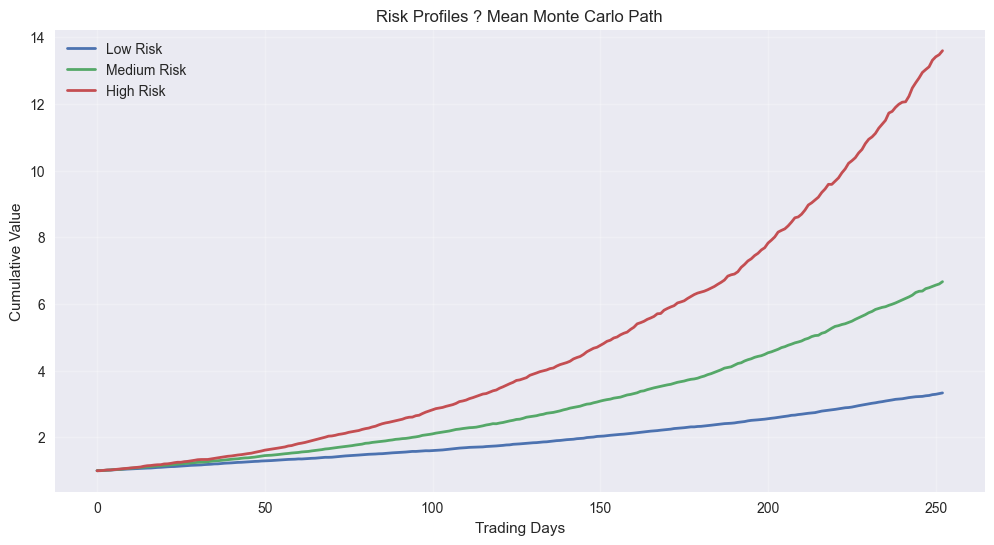

## Capital allocation scenarios

,Profile,Portfolio Allocation,Lending Allocation,Expected Portfolio Value,95% Portfolio Floor,95% Portfolio Ceiling,Projected Lending Profit
0,Low Risk,"$12,000.00","$3,000.00","$39,998.88","$25,539.08","$64,943.19",$232.90
1,Medium Risk,"$9,000.00","$6,000.00","$60,028.63","$25,654.79","$113,227.87",$628.28
2,High Risk,"$7,500.00","$7,500.00","$101,973.19","$31,308.92","$254,609.06","$1,120.07"


In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
for profile_name, path in profile_paths.items():
    ax.plot(path.values, label=profile_name, linewidth=2)
ax.set_title('Risk Profiles ? Mean Monte Carlo Path')
ax.set_xlabel('Trading Days')
ax.set_ylabel('Cumulative Value')
ax.legend()
ax.grid(alpha=0.25)
plt.show()

def projected_lending_profit(principal: float, annual_rate: float, years: int) -> float:
    months = max(int(years * 12), 1)
    return principal * ((1 + annual_rate / 12) ** months - 1)

allocations = {
    'Low Risk': {'portfolio_pct': 0.80, 'lending_pct': 0.20, 'lending_rate': 0.075},
    'Medium Risk': {'portfolio_pct': 0.60, 'lending_pct': 0.40, 'lending_rate': 0.10},
    'High Risk': {'portfolio_pct': 0.50, 'lending_pct': 0.50, 'lending_rate': 0.14},
}

scenario_rows = []
for _, row in profile_summary.iterrows():
    settings = allocations[row['Profile']]
    portfolio_capital = capital * settings['portfolio_pct']
    lending_capital = capital * settings['lending_pct']
    lending_profit = projected_lending_profit(lending_capital, settings['lending_rate'], duration_years)

    scenario_rows.append({
        'Profile': row['Profile'],
        'Portfolio Allocation': f'${portfolio_capital:,.2f}',
        'Lending Allocation': f'${lending_capital:,.2f}',
        'Expected Portfolio Value': f"${row['Expected Terminal Value'] * portfolio_capital:,.2f}",
        '95% Portfolio Floor': f"${row['95% CI Lower'] * portfolio_capital:,.2f}",
        '95% Portfolio Ceiling': f"${row['95% CI Upper'] * portfolio_capital:,.2f}",
        'Projected Lending Profit': f'${lending_profit:,.2f}',
    })

scenario_table = pd.DataFrame(scenario_rows)
display(Markdown('## Capital allocation scenarios'))
scenario_table